# American Option Pricing Methodologies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from scipy import interpolate
from numba import jit
import time
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic parameters for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)
color_palette = sns.color_palette("viridis", 5)
plt.rcParams['figure.figsize'] = [12, 8]

## Utility Functions

In [2]:
def implied_vol(price, S, K, T, r, q, option_type, is_american=False):
    """Calculate implied volatility using bisection method"""
    precision = 0.00001
    upper_vol = 5.0  # upper volatility boundary
    lower_vol = 0.00001  # lower volatility boundary

    # Function to calculate price difference
    def difference(sigma):
        if is_american:
            calculated_price = binomial_tree(S, K, r, q, sigma, T, 100, option_type)
        else:
            calculated_price = black_scholes(S, K, T, r, sigma, q, option_type)
        return calculated_price - price

    # Check if volatility is bracketed
    if difference(lower_vol) * difference(upper_vol) > 0:
        return np.nan

    # Bisection algorithm
    while upper_vol - lower_vol > precision:
        mid_vol = (upper_vol + lower_vol) / 2
        diff = difference(mid_vol)

        if abs(diff) < precision:
            return mid_vol

        if diff * difference(lower_vol) < 0:
            upper_vol = mid_vol
        else:
            lower_vol = mid_vol

    return (upper_vol + lower_vol) / 2

def black_scholes(S, K, T, r, sigma, q, option_type):
    """Standard Black-Scholes formula for European options"""
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type.lower() == 'call':
        price = S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)

    return price

## Pricing Methodologies

### Binomial Tree

In [3]:
@jit(nopython=True)
def binomial_tree(S, K, r, q, sigma, T, steps, option_type):
    """Cox-Ross-Rubinstein Binomial Tree Model for American Options"""
    dt = T / steps
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp((r - q) * dt) - d) / (u - d)

    # Initialize the stock price tree
    stock = np.zeros((steps + 1, steps + 1))
    for i in range(steps + 1):
        for j in range(i + 1):
            stock[j, i] = S * (u ** (i - j)) * (d ** j)

    # Initialize the option price tree
    option = np.zeros((steps + 1, steps + 1))

    # Fill in the terminal nodes
    if option_type.lower() == 'call':
        option[:, steps] = np.maximum(0, stock[:, steps] - K)
    else:
        option[:, steps] = np.maximum(0, K - stock[:, steps])

    # Backward induction
    for i in range(steps - 1, -1, -1):
        for j in range(i + 1):
            # Expected option value
            option_value = np.exp(-r * dt) * (p * option[j, i + 1] + (1 - p) * option[j + 1, i + 1])

            # Immediate exercise value
            if option_type.lower() == 'call':
                exercise = max(0, stock[j, i] - K)
            else:
                exercise = max(0, K - stock[j, i])

            # Take the maximum (American option)
            option[j, i] = max(option_value, exercise)

    return option[0, 0]

### Trinomial Tree

In [4]:
def trinomial_tree(S, K, r, q, sigma, T, steps, option_type):
    """Trinomial Tree Model for American Options"""
    dt = T / steps
    u = np.exp(sigma * np.sqrt(2 * dt))
    d = 1 / u
    m = 1  # middle state

    pu = ((np.exp((r - q) * dt/2) - np.exp(-sigma * np.sqrt(dt/2))) /
          (np.exp(sigma * np.sqrt(dt/2)) - np.exp(-sigma * np.sqrt(dt/2)))) ** 2
    pd = ((np.exp(sigma * np.sqrt(dt/2)) - np.exp((r - q) * dt/2)) /
          (np.exp(sigma * np.sqrt(dt/2)) - np.exp(-sigma * np.sqrt(dt/2)))) ** 2
    pm = 1 - pu - pd

    # Initialize arrays
    stock_prices = np.zeros((2 * steps + 1))
    option_values = np.zeros((2 * steps + 1))

    # Terminal stock prices and option values
    for i in range(2 * steps + 1):
        stock_prices[i] = S * (u ** (steps - i))
        if option_type.lower() == 'call':
            option_values[i] = max(0, stock_prices[i] - K)
        else:
            option_values[i] = max(0, K - stock_prices[i])

    # Backward induction
    for step in range(steps - 1, -1, -1):
        for i in range(2 * step + 1):
            stock_price = S * (u ** (step - i))

            # Expected option value
            expected_value = (pu * option_values[i] +
                              pm * option_values[i + 1] +
                              pd * option_values[i + 2]) * np.exp(-r * dt)

            # Immediate exercise value
            if option_type.lower() == 'call':
                exercise_value = max(0, stock_price - K)
            else:
                exercise_value = max(0, K - stock_price)

            # American option: max of continuation and exercise
            option_values[i] = max(expected_value, exercise_value)

    # Return the option price at the root node
    return option_values[0]

### Finite Difference

In [26]:
def finite_difference_explicit(S, K, r, q, sigma, T, S_max=None, M=100, N=100, option_type='put'):
    """Explicit Finite Difference Method for American Options"""
    # Set reasonable default for S_max if not provided
    if S_max is None:
        S_max = 4 * K  # Set max price sufficiently high

    # Set up grid parameters
    dt = T / N
    dS = S_max / M

    # Initialize price grid
    V = np.zeros((M+1, N+1))

    # Create stock price grid
    S_values = np.linspace(0, S_max, M+1)

    # Terminal conditions (at maturity)
    if option_type.lower() == 'call':
        V[:, N] = np.maximum(S_values - K, 0)
    else:
        V[:, N] = np.maximum(K - S_values, 0)

    # Precompute coefficients for the finite difference scheme
    i_values = np.arange(0, M+1)
    a = 0.5 * dt * (sigma**2 * i_values**2 - (r - q) * i_values)
    b = 1 - dt * (sigma**2 * i_values**2 + r)
    c = 0.5 * dt * (sigma**2 * i_values**2 + (r - q) * i_values)

    # Boundary conditions
    if option_type.lower() == 'call':
        # Lower boundary (S=0)
        V[0, :] = 0
        # Upper boundary (S=S_max)
        V[M, 0:N] = S_max - K * np.exp(-r * dt * (N - np.arange(N)))
    else:
        # Lower boundary (S=0)
        V[0, 0:N] = K * np.exp(-r * dt * (N - np.arange(N)))
        # Upper boundary (S=S_max)
        V[M, :] = 0

    # Main finite difference algorithm (backward in time)
    for j in range(N-1, -1, -1):
        for i in range(1, M):
            # Calculate continuation value
            cont_value = a[i] * V[i-1, j+1] + b[i] * V[i, j+1] + c[i] * V[i+1, j+1]

            # Calculate early exercise value
            if option_type.lower() == 'call':
                exercise_value = max(0, S_values[i] - K)
            else:
                exercise_value = max(0, K - S_values[i])

            # American option value is max of continuation and exercise
            V[i, j] = max(cont_value, exercise_value)

    # Interpolate to get the option price at spot price S
    option_price = np.interp(S, S_values, V[:, 0])

    return option_price


### Monte Carlo

In [22]:
def montecarlo_lsm(S, K, r, q, sigma, T, num_simulations=10000, num_steps=50, option_type='put'):
    """Least Squares Monte Carlo (Longstaff-Schwartz) for American Options"""
    dt = T / num_steps
    discount = np.exp(-r * dt)

    # Generate random numbers for simulation
    np.random.seed(42)  # For reproducibility
    Z = np.random.standard_normal((num_simulations, num_steps))

    # Initialize stock price paths
    S_paths = np.zeros((num_simulations, num_steps + 1))
    S_paths[:, 0] = S

    # Simulate asset price paths
    for t in range(1, num_steps + 1):
        S_paths[:, t] = S_paths[:, t-1] * np.exp((r - q - 0.5 * sigma**2) * dt +
                                              sigma * np.sqrt(dt) * Z[:, t-1])

    # Initialize payoff matrix
    if option_type.lower() == 'call':
        payoff = np.maximum(S_paths - K, 0)
    else:
        payoff = np.maximum(K - S_paths, 0)

    # Initialize cash flow matrix with final values
    cash_flows = np.zeros_like(S_paths)
    cash_flows[:, -1] = payoff[:, -1]

    # Backward induction through time steps
    for t in range(num_steps - 1, 0, -1):
        # Identify in-the-money paths
        if option_type.lower() == 'call':
            itm_paths = S_paths[:, t] > K
        else:
            itm_paths = S_paths[:, t] < K

        # Skip if no paths are in-the-money
        if np.sum(itm_paths) <= 5:  # Need a minimum number for regression
            continue

        # Extract in-the-money paths and corresponding stock prices
        S_itm = S_paths[itm_paths, t]

        # Calculate discounted future cash flows (not immediate exercise)
        future_cash_flows = np.sum(cash_flows[itm_paths, t+1:] *
                                 np.power(discount, np.arange(1, num_steps + 1 - t)),
                                 axis=1)

        # Prepare basis functions for regression (polynomial basis)
        X = np.column_stack([
            np.ones(len(S_itm)),
            S_itm,
            S_itm**2,
            S_itm**3
        ])

        # Handle potential numerical issues in regression
        if np.any(np.isnan(X)) or np.any(np.isnan(future_cash_flows)):
            continue

        # Solve the least squares problem with regularization
        try:
            beta, _, _, _ = np.linalg.lstsq(X, future_cash_flows, rcond=1e-6)
        except np.linalg.LinAlgError:
            continue

        # Calculate continuation value (expected future cash flows)
        continuation_value = np.dot(X, beta)

        # Immediate exercise value for in-the-money paths
        immediate_exercise = payoff[itm_paths, t]

        # Exercise decision: exercise when immediate payoff > continuation value
        exercise = immediate_exercise > continuation_value

        # Update cash flows
        # If exercising at time t, record the payoff and set future cash flows to 0
        cash_flows[itm_paths, t] = np.where(exercise, immediate_exercise, 0)

        # Set future cash flows to 0 for exercised paths
        for path_idx, exercised in zip(np.where(itm_paths)[0], exercise):
            if exercised:
                cash_flows[path_idx, t+1:] = 0
            else:
                # Keep future cash flows unchanged for non-exercised paths
                pass

    # Check for exercise at t=0 (first period)
    immediate_exercise_t0 = payoff[:, 0]
    future_cash_flows_t0 = np.sum(cash_flows[:, 1:] *
                                np.power(discount, np.arange(1, num_steps + 1)),
                                axis=1)

    # Calculate the optimal value at t=0
    option_value = np.mean(np.maximum(immediate_exercise_t0, future_cash_flows_t0))

    return option_value

### Analytical Barone Adesi Whaley

In [19]:
def analytical_barone_adesi_whaley(S, K, r, q, sigma, T, option_type):
    """Barone-Adesi and Whaley Approximation for American Options"""

    # European option value using Black-Scholes
    european_price = black_scholes(S, K, T, r, sigma, q, option_type)

    # For very short maturities, return the European price
    if T <= 0.1:
        return european_price

    # Parameters for the approximation
    if option_type.lower() == 'call':
        if q >= r:  # Never optimal to exercise American calls early if q >= r
            return european_price

        # Find critical stock price using Newton-Raphson
        N = 100  # Maximum iterations
        S_critical = K  # Initial guess

        for _ in range(N):
            if S_critical <= K:
                S_critical = 1.2 * K
                continue

            d1 = (np.log(S_critical / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
            lambda_val = 2 * (r - q) / (sigma**2)
            b = 2 * (r - q) / (sigma**2) + 1
            M = 2 * r / (sigma**2)
            q1 = -(N - 1 + np.sqrt((N - 1)**2 + 4 * M/b)) / 2
            q2 = -(N - 1 - np.sqrt((N - 1)**2 + 4 * M/b)) / 2

            LHS = S_critical - K
            RHS = european_price + (1 - np.exp(-q * T) * norm.cdf(d1)) * S_critical / q1

            diff = LHS - RHS
            f_prime = 1 - (1 / q1) * np.exp(-q * T) * norm.pdf(d1) / (sigma * np.sqrt(T))

            if abs(diff) < 0.001:
                break

            S_critical = S_critical - diff / f_prime

        # American option premium
        if S >= S_critical:
            return S - K
        else:
            d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
            A2 = (S / q2) * (1 - np.exp(-q * T) * norm.cdf(d1))
            return european_price + A2 * (S / S_critical)**q2

    else:  # Put option
        # Find critical stock price using Newton-Raphson
        N = 100  # Maximum iterations
        S_critical = K * 0.8  # Initial guess

        for _ in range(N):
            if S_critical >= K:
                S_critical = 0.8 * K
                continue

            d1 = (np.log(S_critical / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
            lambda_val = 2 * (r - q) / (sigma**2)
            b = 2 * (r - q) / (sigma**2) + 1
            M = 2 * r / (sigma**2)
            q1 = -(N - 1 + np.sqrt((N - 1)**2 + 4 * M/b)) / 2
            q2 = -(N - 1 - np.sqrt((N - 1)**2 + 4 * M/b)) / 2

            LHS = K - S_critical
            RHS = european_price - (1 - np.exp(-q * T) * norm.cdf(-d1)) * S_critical / q1

            diff = LHS - RHS
            f_prime = -1 - (1 / q1) * np.exp(-q * T) * norm.pdf(-d1) / (sigma * np.sqrt(T))

            if abs(diff) < 0.001:
                break

            S_critical = S_critical - diff / f_prime

        # American option premium
        if S <= S_critical:
            return K - S
        else:
            d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
            A1 = -(S / q1) * (1 - np.exp(-q * T) * norm.cdf(-d1))
            return european_price + A1 * (S / S_critical)**q1


## Benchmarking different methods

In [24]:
# Benchmarking Framework
def benchmark_methods(S, K, r, q, sigma, T, option_type, methods=None):
    """Compare different pricing methods and their performance"""
    if methods is None:
        methods = {
            'Black-Scholes (European)':
                lambda: black_scholes(S, K, T, r, sigma, q, option_type),
            'Binomial Tree (50 steps)':
                lambda: binomial_tree(S, K, r, q, sigma, T, 50, option_type),
            'Binomial Tree (100 steps)':
                lambda: binomial_tree(S, K, r, q, sigma, T, 100, option_type),
            'Trinomial Tree (50 steps)':
                lambda: trinomial_tree(S, K, r, q, sigma, T, 50, option_type),
            'Finite Difference':
                lambda: finite_difference_explicit(S, K, r, q, sigma, T, 3*S, 100, 100, option_type),
            'Monte Carlo LSM':
                lambda: montecarlo_lsm(S, K, r, q, sigma, T, 10000, 50, option_type),
            'Barone-Adesi-Whaley':
                lambda: analytical_barone_adesi_whaley(S, K, r, q, sigma, T, option_type)
        }

    results = []

    for method_name, method_func in methods.items():
        start_time = time.time()
        try:
            price = method_func()
            elapsed_time = time.time() - start_time
            results.append({
                'Method': method_name,
                'Price': price,
                'Time (s)': elapsed_time
            })
        except Exception as e:
            results.append({
                'Method': method_name,
                'Price': None,
                'Time (s)': time.time() - start_time,
                'Error': str(e)
            })

    return pd.DataFrame(results)

### Early Exercise Premium Analysis

In [8]:
def early_exercise_premium(S, K, r, q, sigma, T, option_type):
    """Calculate early exercise premium across different dividend yields"""
    q_values = np.linspace(0, 0.08, 9)
    premium = []

    for q_val in q_values:
        european = black_scholes(S, K, T, r, sigma, q_val, option_type)
        american = binomial_tree(S, K, r, q_val, sigma, T, 100, option_type)
        premium.append({
            'Dividend Yield': q_val,
            'European Price': european,
            'American Price': american,
            'Early Exercise Premium': american - european,
            'Premium %': (american - european) / european * 100 if european > 0 else np.nan
        })

    return pd.DataFrame(premium)

### Single-Name Specific Analysis

In [9]:
def analyze_single_name_effects():
    """Analyze specific effects of transitioning to single name options"""
    # Higher implied volatility ranges for single names
    index_vol_range = np.linspace(0.1, 0.3, 5)
    single_name_vol_range = np.linspace(0.2, 0.6, 5)

    index_results = []
    single_name_results = []

    # Standard parameters
    S = 100
    K = 100
    r = 0.05
    T = 1.0
    option_type = 'put'

    # Index-like parameters (low div yield, low vol)
    index_q = 0.02

    # Single name parameters (potentially higher div yield, higher vol)
    single_name_q = 0.04

    for idx_vol, single_vol in zip(index_vol_range, single_name_vol_range):
        # Index
        european_idx = black_scholes(S, K, T, r, idx_vol, index_q, option_type)
        american_idx = binomial_tree(S, K, r, index_q, idx_vol, T, 100, option_type)
        early_ex_idx = american_idx - european_idx

        index_results.append({
            'Volatility': idx_vol,
            'European': european_idx,
            'American': american_idx,
            'Early Exercise Premium': early_ex_idx,
            'Premium %': early_ex_idx / european_idx * 100
        })

        # Single name
        european_single = black_scholes(S, K, T, r, single_vol, single_name_q, option_type)
        american_single = binomial_tree(S, K, r, single_name_q, single_vol, T, 100, option_type)
        early_ex_single = american_single - european_single

        single_name_results.append({
            'Volatility': single_vol,
            'European': european_single,
            'American': american_single,
            'Early Exercise Premium': early_ex_single,
            'Premium %': early_ex_single / european_single * 100
        })

    return pd.DataFrame(index_results), pd.DataFrame(single_name_results)

### Corporate Action Analysis

In [10]:
def analyze_corporate_actions(S, K, r, sigma, T, option_type):
    """Analyze pricing impact of corporate actions like special dividends"""
    # Regular pricing with continuous dividend yield
    regular_q = 0.02
    regular_price = binomial_tree(S, K, r, regular_q, sigma, T, 100, option_type)

    # Special dividend scenarios (discrete dividends)
    dividend_amounts = [1, 2, 3, 5, 7]
    dividend_times = [0.25, 0.5, 0.75]  # When dividends occur (as fraction of T)

    results = []

    for div_time in dividend_times:
        for div_amount in dividend_amounts:
            # Adjust stock price after dividend
            S_adjusted = S
            if div_time < T:
                S_adjusted = S - div_amount * np.exp(-r * div_time)

            # Calculate using adjusted stock price and no continuous dividend
            special_price = binomial_tree(S_adjusted, K, r, 0, sigma, T, 100, option_type)

            results.append({
                'Dividend Time': div_time,
                'Dividend Amount': div_amount,
                'Regular Price': regular_price,
                'Special Dividend Price': special_price,
                'Price Difference': special_price - regular_price,
                'Price Difference %': (special_price - regular_price) / regular_price * 100
            })

    return pd.DataFrame(results)

### Analysis for hard-to-borrow stocks

In [11]:
def analyze_hard_to_borrow(S, K, r, sigma, T, option_type):
    """Analyze impact of stock borrow costs on option pricing"""
    q_values = np.linspace(0, 0.1, 6)  # Dividend yield / borrow cost

    results = []

    for q in q_values:
        european = black_scholes(S, K, T, r, sigma, q, option_type)
        american = binomial_tree(S, K, r, q, sigma, T, 100, option_type)

        results.append({
            'Borrow Cost': q,
            'European Price': european,
            'American Price': american,
            'Early Exercise Premium': american - european,
            'Premium %': (american - european) / european * 100 if european > 0 else np.nan
        })

    return pd.DataFrame(results)

### Skew Analysis

In [12]:
def analyze_volatility_skew(S, r, q, T):
    """Analyze volatility skew differences between index and single name options"""
    # Typical index skew parameters
    index_atm_vol = 0.20
    index_skew_steepness = 0.04

    # Typical single name skew parameters
    single_atm_vol = 0.35
    single_skew_steepness = 0.06

    # Generate strike levels (as percentage of spot)
    moneyness = np.linspace(0.7, 1.3, 13)
    strikes = S * moneyness

    results = []

    for K in strikes:
        # Index vol skew
        index_moneyness = np.log(K/S)
        index_vol = index_atm_vol + index_skew_steepness * index_moneyness

        # Single name vol skew
        single_moneyness = np.log(K/S)
        single_vol = single_atm_vol + single_skew_steepness * single_moneyness

        # Calculate prices with skewed vols
        index_put = binomial_tree(S, K, r, q, index_vol, T, 100, 'put')
        single_put = binomial_tree(S, K, r, q, single_vol, T, 100, 'put')

        results.append({
            'Strike': K,
            'Moneyness': K/S,
            'Index Vol': index_vol,
            'Single Name Vol': single_vol,
            'Index Put Price': index_put,
            'Single Name Put Price': single_put,
            'Price Difference': single_put - index_put,
            'Price Difference %': (single_put - index_put) / index_put * 100
        })

    return pd.DataFrame(results)

## Run all the analyses

### 1. Base case for a generic put option

In [27]:
print("Base Case Analysis")
S = 100
K = 100
r = 0.05
q = 0.02
sigma = 0.2
T = 1.0
option_type = 'put'

benchmark_results = benchmark_methods(S, K, r, q, sigma, T, option_type)
benchmark_results

Base Case Analysis


,Method,Price,Time (s)
0,Black-Scholes (European),6.330081,0.000682
1,Binomial Tree (50 steps),6.641549,0.000356
2,Binomial Tree (100 steps),6.651030,0.001134
3,Trinomial Tree (50 steps),6.644959,0.006762
4,Finite Difference,6.685847,0.019063
5,Monte Carlo LSM,6.607322,0.208842
6,Barone-Adesi-Whaley,6.330672,0.001504


### 2. Early exercise premium analysis

In [28]:
premium_analysis = early_exercise_premium(S, K, r, q, sigma, T, option_type)
premium_analysis

,Dividend Yield,European Price,American Price,Early Exercise Premium,Premium %
0,0.00,5.573526,6.082354,0.508828,9.129380
1,0.01,5.944257,6.358347,0.414090,6.966227
2,0.02,6.330081,6.651030,0.320950,5.070231
3,0.03,6.730918,6.962052,0.231134,3.433919
4,0.04,7.146642,7.292938,0.146295,2.047052
5,0.05,7.577082,7.646615,0.069533,0.917670
6,0.06,8.022021,8.032418,0.010397,0.129607
7,0.07,8.481197,8.467674,-0.013523,-0.159446
8,0.08,8.954306,8.936252,-0.018055,-0.201632


### 3. Single-name specific effects

In [29]:
print("\nComparing Index vs Single Name Characteristics")
index_results, single_name_results = analyze_single_name_effects()
print("Index-like Results:")
index_results


Comparing Index vs Single Name Characteristics
Index-like Results:


,Volatility,European,American,Early Exercise Premium,Premium %
0,0.10,2.574424,2.891527,0.317103,12.317455
1,0.15,4.439948,4.758460,0.318512,7.173769
2,0.20,6.330081,6.651030,0.320950,5.070231
3,0.25,8.226837,8.552325,0.325488,3.956419
4,0.30,10.123356,10.454830,0.331474,3.274344


In [30]:
print("\nSingle Name Results:")
single_name_results


Single Name Results:


,Volatility,European,American,Early Exercise Premium,Premium %
0,0.2,7.146642,7.292938,0.146295,2.047052
1,0.3,10.927299,11.102130,0.174830,1.599942
2,0.4,14.681278,14.885833,0.204555,1.393304
3,0.5,18.398531,18.633546,0.235015,1.277355
4,0.6,22.069924,22.336105,0.266181,1.206080


### 4. Corporate action analysis

In [31]:
corporate_action_results = analyze_corporate_actions(S, K, r, sigma, T, option_type)
corporate_action_results

,Dividend Time,Dividend Amount,Regular Price,Special Dividend Price,Price Difference,Price Difference %
0,0.25,1,6.65103,6.517416,-0.133614,-2.008927
1,0.25,2,6.65103,6.961982,0.310951,4.675235
2,0.25,3,6.65103,7.418006,0.766975,11.531678
3,0.25,5,6.65103,8.426387,1.775357,26.692957
4,0.25,7,6.65103,9.530385,2.879355,43.291861
5,0.50,1,6.65103,6.511963,-0.139067,-2.090913
6,0.50,2,6.65103,6.950813,0.299783,4.507315
7,0.50,3,6.65103,7.400736,0.749706,11.272029
8,0.50,5,6.65103,8.393125,1.742095,26.192858
9,0.50,7,6.65103,9.480964,2.829933,42.548799


### 5. Hard-to-borrow analysis

In [32]:
htb_results = analyze_hard_to_borrow(S, K, r, sigma, T, option_type)
htb_results

,Borrow Cost,European Price,American Price,Early Exercise Premium,Premium %
0,0.00,5.573526,6.082354,0.508828,9.129380
1,0.02,6.330081,6.651030,0.320950,5.070231
2,0.04,7.146642,7.292938,0.146295,2.047052
3,0.06,8.022021,8.032418,0.010397,0.129607
4,0.08,8.954306,8.936252,-0.018055,-0.201632
5,0.10,9.940903,9.921921,-0.018981,-0.190943


### 6. Volatility skew analysis

In [33]:
skew_results = analyze_volatility_skew(S, r, q, T)
skew_results

,Strike,Moneyness,Index Vol,Single Name Vol,Index Put Price,Single Name Put Price,Price Difference,Price Difference %
0,70.0,0.70,0.185733,0.328600,0.103872,1.583318,1.479447,1424.304367
1,75.0,0.75,0.188493,0.332739,0.306733,2.561067,2.254334,734.950466
2,80.0,0.80,0.191074,0.336611,0.731569,3.862368,3.130799,427.956759
3,85.0,0.85,0.193499,0.340249,1.495773,5.504843,4.009070,268.026613
4,90.0,0.90,0.195786,0.343678,2.708057,7.484855,4.776798,176.392051
5,95.0,0.95,0.197948,0.346922,4.418170,9.779768,5.361598,121.353374
6,100.0,1.00,0.200000,0.350000,6.651030,12.354642,5.703611,85.755305
7,105.0,1.05,0.201952,0.352927,9.459154,15.306915,5.847761,61.821188
8,110.0,1.10,0.203812,0.355719,12.758633,18.491446,5.732813,44.932814
9,115.0,1.15,0.205590,0.358386,16.511289,21.873406,5.362117,32.475457


## Visualizations

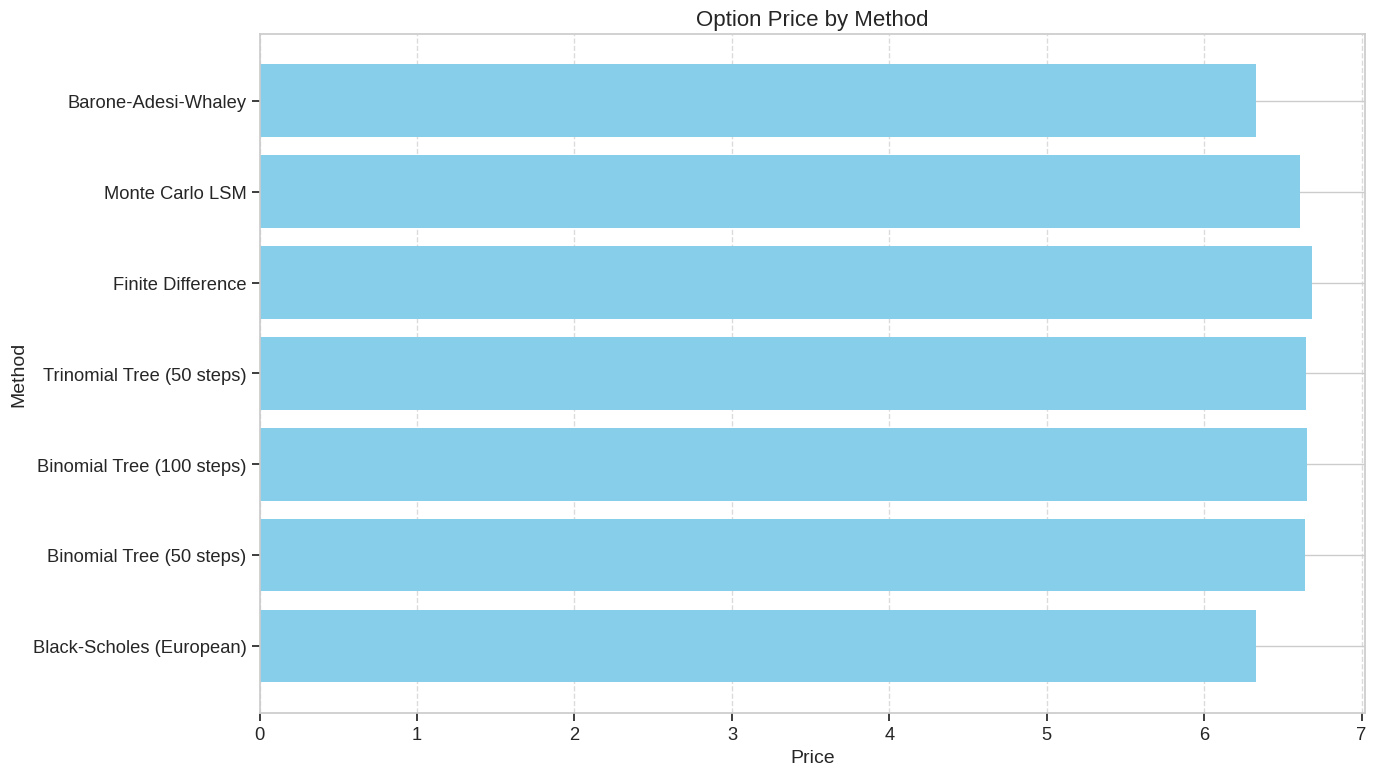

In [34]:
# 1. Method Comparison
plt.figure(figsize=(14, 8))
plt.barh(benchmark_results['Method'], benchmark_results['Price'], color='skyblue')
plt.title('Option Price by Method', fontsize=16)
plt.xlabel('Price', fontsize=14)
plt.ylabel('Method', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

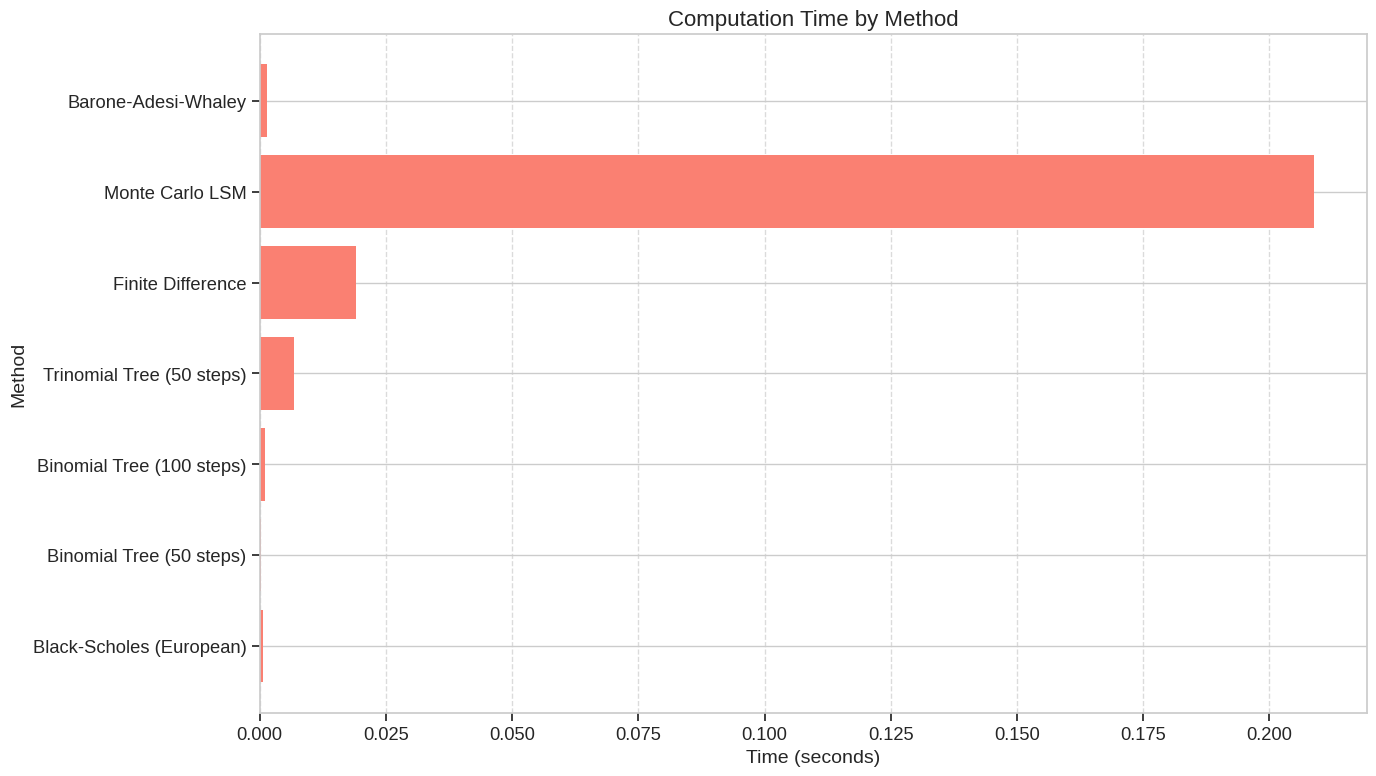

In [35]:
# 2. Performance Comparison
plt.figure(figsize=(14, 8))
plt.barh(benchmark_results['Method'], benchmark_results['Time (s)'], color='salmon')
plt.title('Computation Time by Method', fontsize=16)
plt.xlabel('Time (seconds)', fontsize=14)
plt.ylabel('Method', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

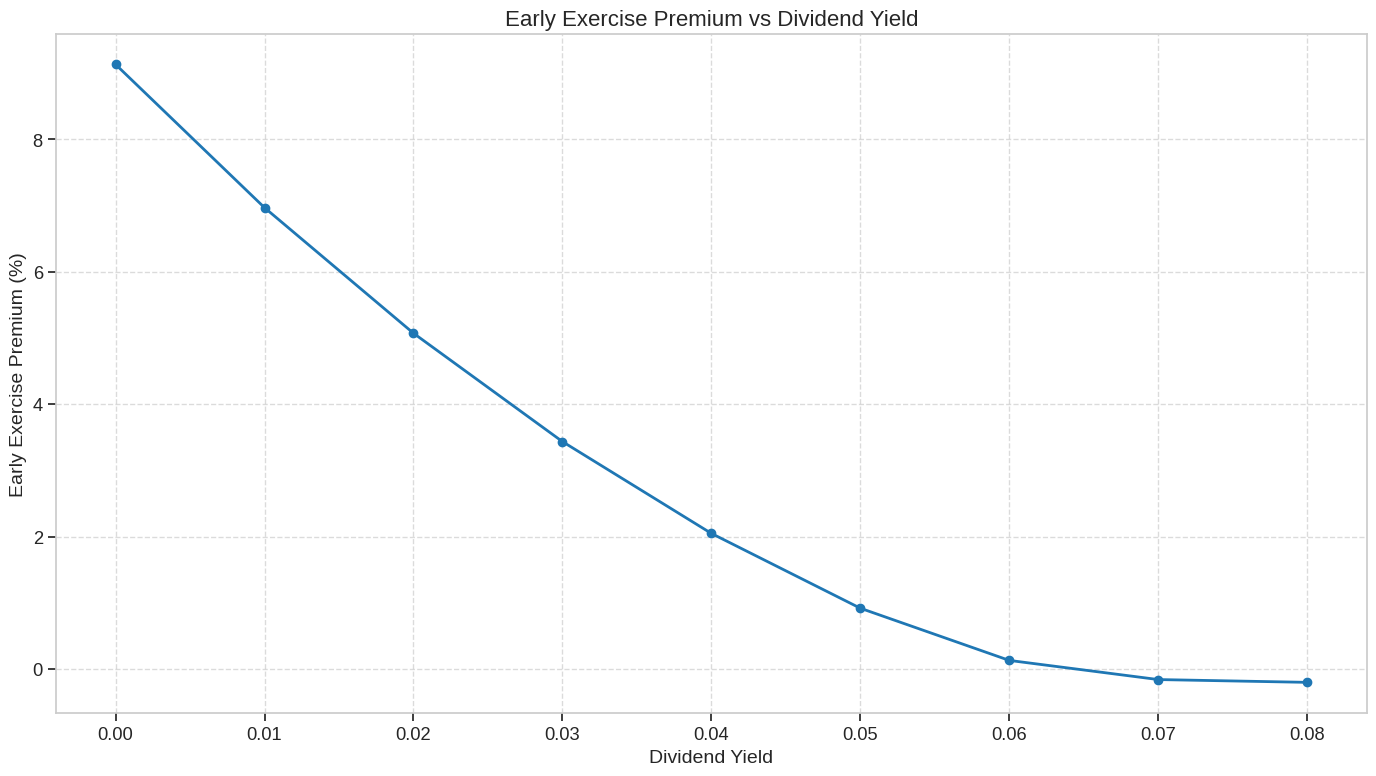

In [36]:
# 3. Early Exercise Premium
plt.figure(figsize=(14, 8))
plt.plot(premium_analysis['Dividend Yield'], premium_analysis['Premium %'], 'o-', linewidth=2)
plt.title('Early Exercise Premium vs Dividend Yield', fontsize=16)
plt.xlabel('Dividend Yield', fontsize=14)
plt.ylabel('Early Exercise Premium (%)', fontsize=14)
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()

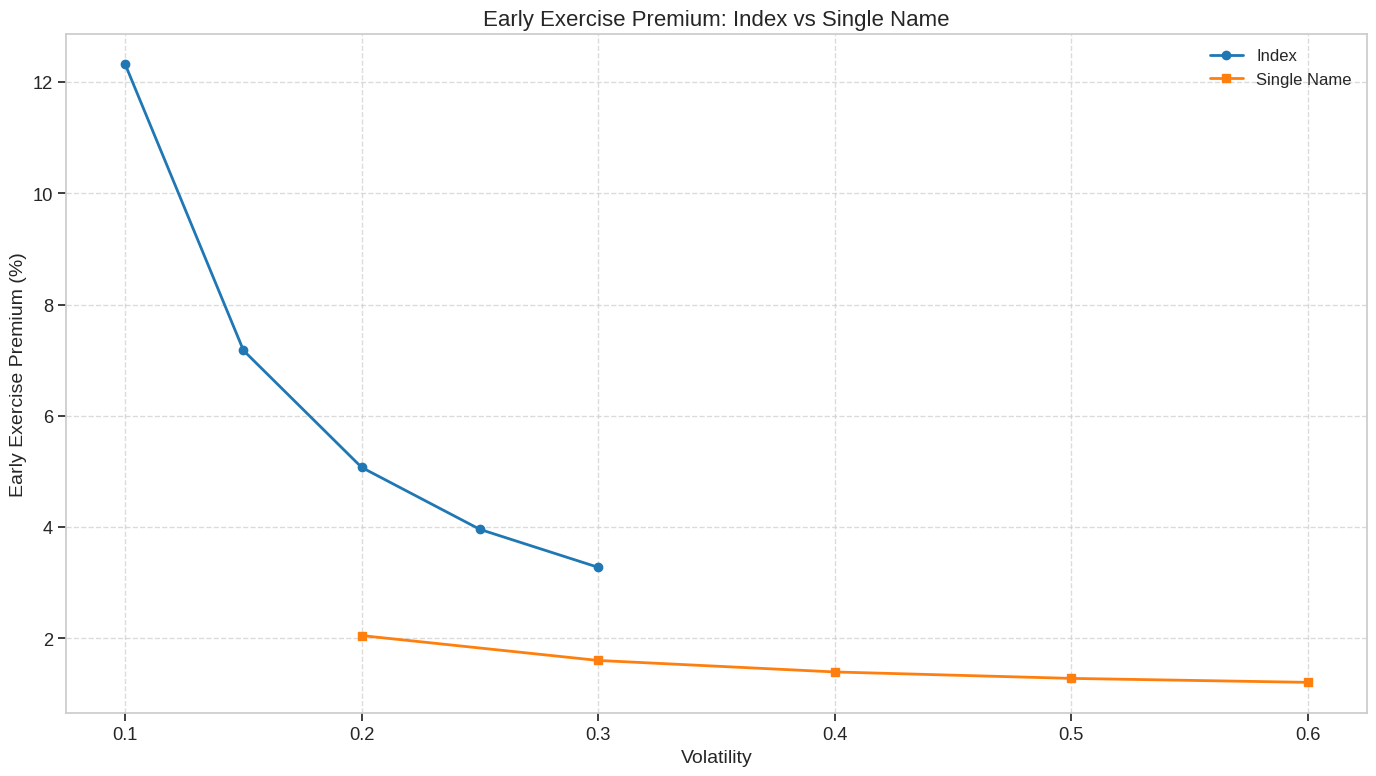

In [37]:
# 4. Index vs Single Name Comparison
plt.figure(figsize=(14, 8))
plt.plot(index_results['Volatility'], index_results['Premium %'], 'o-', label='Index', linewidth=2)
plt.plot(single_name_results['Volatility'], single_name_results['Premium %'], 's-', label='Single Name', linewidth=2)
plt.title('Early Exercise Premium: Index vs Single Name', fontsize=16)
plt.xlabel('Volatility', fontsize=14)
plt.ylabel('Early Exercise Premium (%)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()

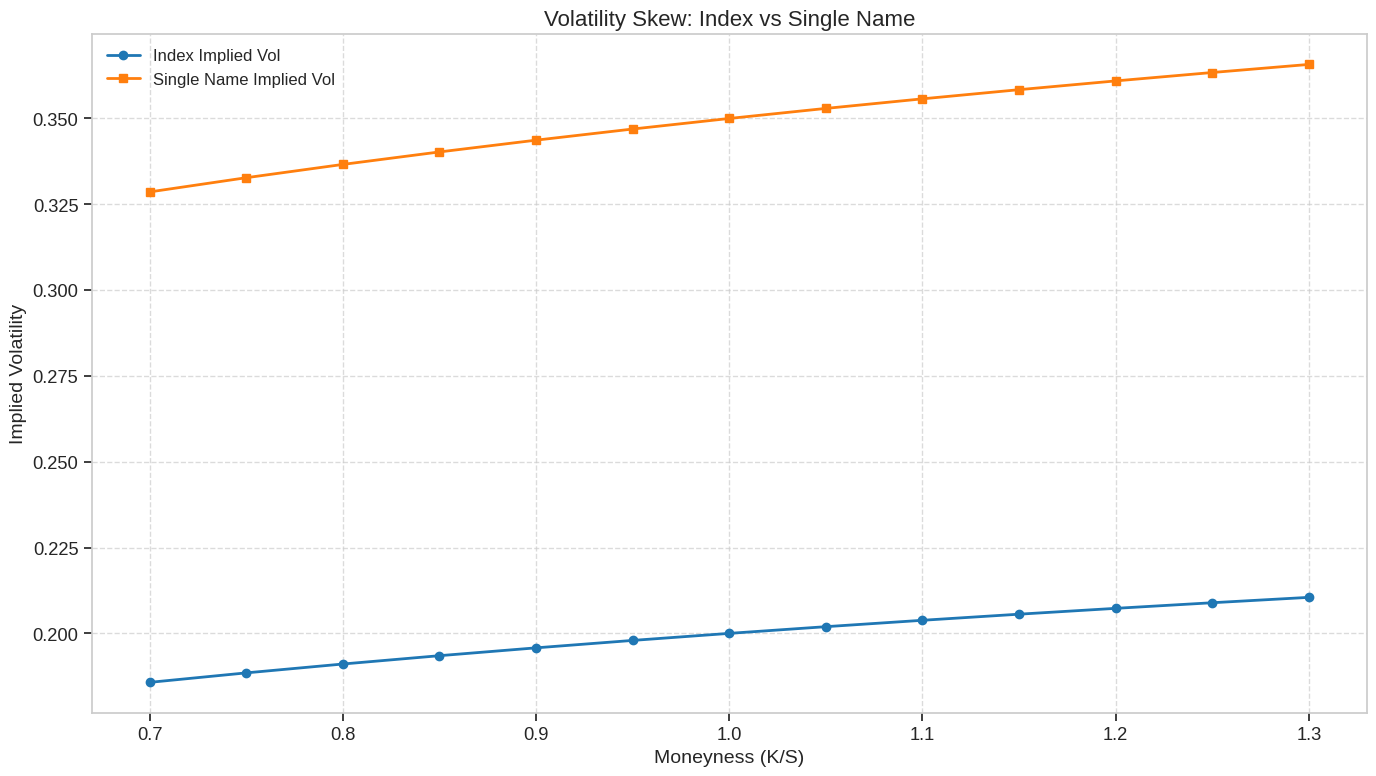

In [38]:
# 5. Volatility Skew Visualization
plt.figure(figsize=(14, 8))
plt.plot(skew_results['Moneyness'], skew_results['Index Vol'], 'o-', label='Index Implied Vol', linewidth=2)
plt.plot(skew_results['Moneyness'], skew_results['Single Name Vol'], 's-', label='Single Name Implied Vol', linewidth=2)
plt.title('Volatility Skew: Index vs Single Name', fontsize=16)
plt.xlabel('Moneyness (K/S)', fontsize=14)
plt.ylabel('Implied Volatility', fontsize=14)
plt.legend(fontsize=12)
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()

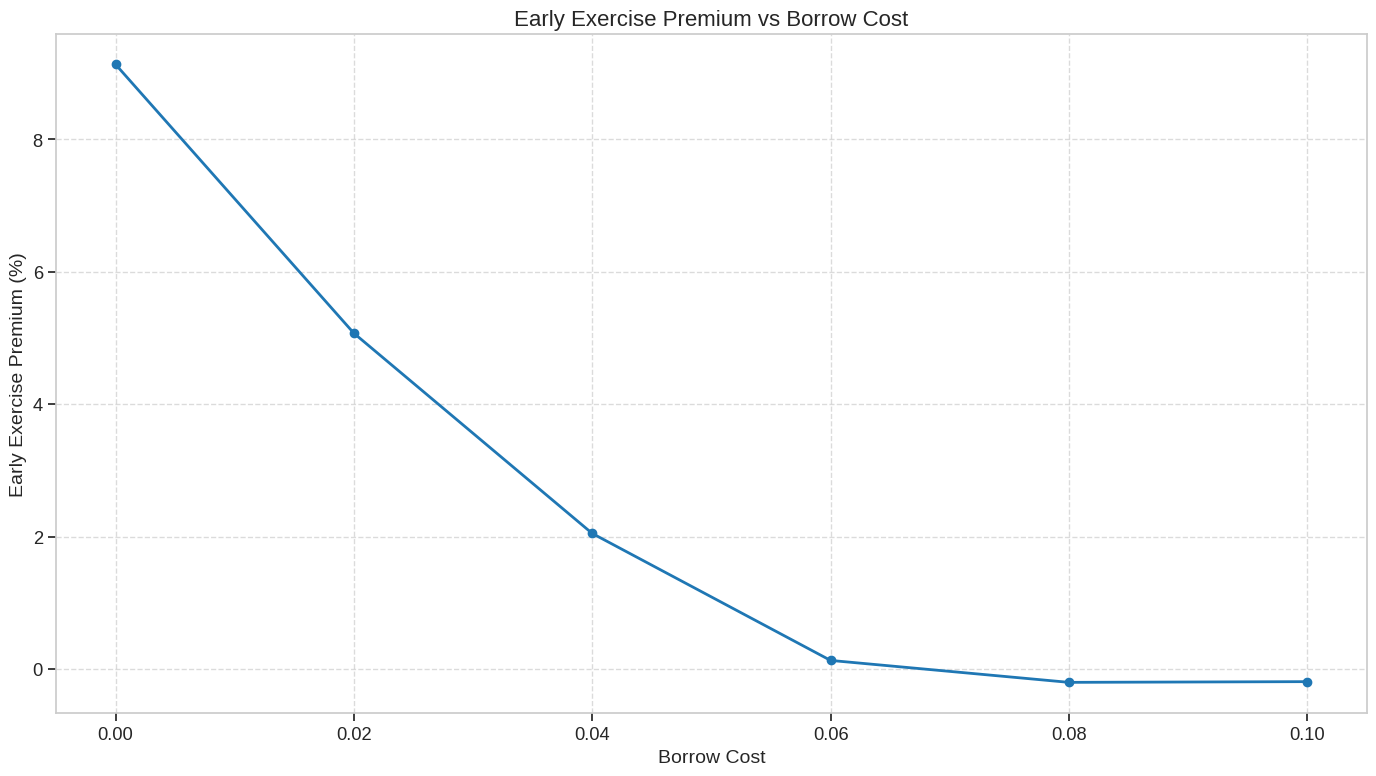

In [39]:
# 6. Hard-to-Borrow Impact
plt.figure(figsize=(14, 8))
plt.plot(htb_results['Borrow Cost'], htb_results['Premium %'], 'o-', linewidth=2)
plt.title('Early Exercise Premium vs Borrow Cost', fontsize=16)
plt.xlabel('Borrow Cost', fontsize=14)
plt.ylabel('Early Exercise Premium (%)', fontsize=14)
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()

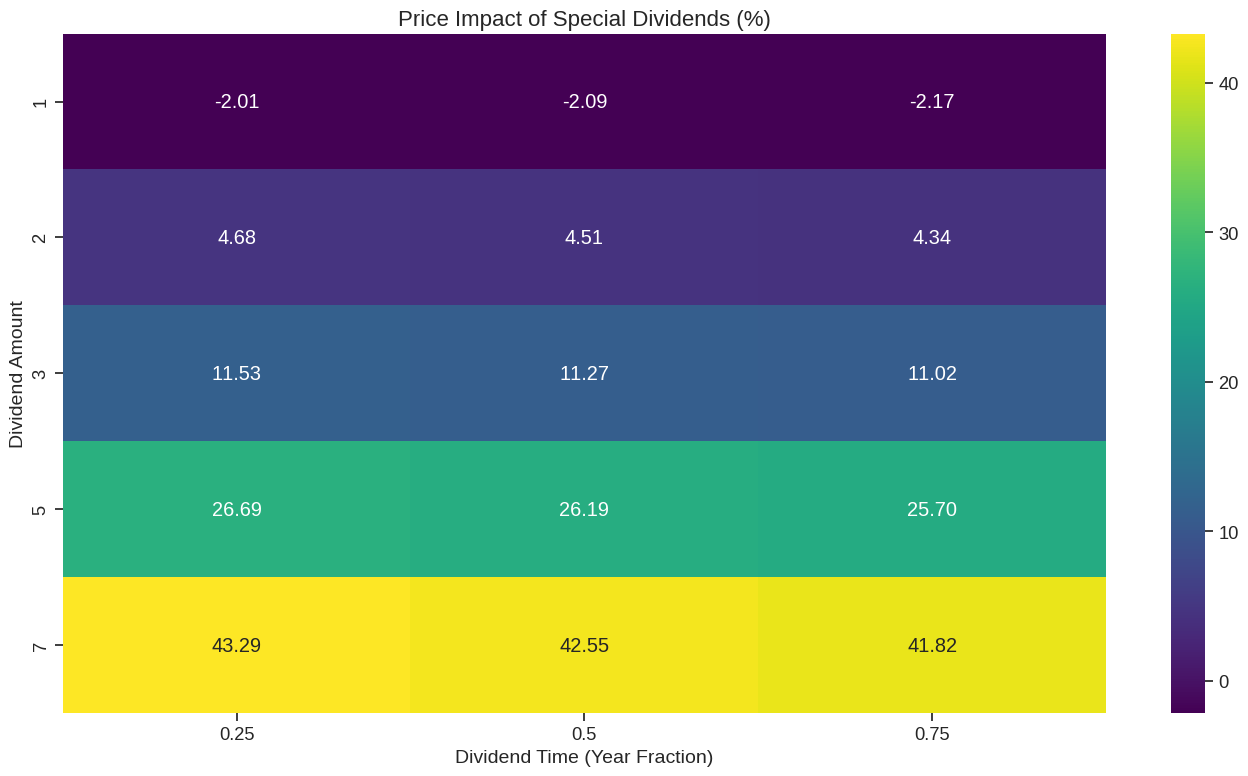

In [40]:
# 7. Special Dividend Impact
plt.figure(figsize=(14, 8))
pivot_data = corporate_action_results.pivot(index='Dividend Amount', columns='Dividend Time', values='Price Difference %')
sns.heatmap(pivot_data, annot=True, cmap='viridis', fmt=".2f")
plt.title('Price Impact of Special Dividends (%)', fontsize=16)
plt.xlabel('Dividend Time (Year Fraction)', fontsize=14)
plt.ylabel('Dividend Amount', fontsize=14)
plt.tight_layout()

### Additional Analyses

In [41]:
# Convergence Analysis
def convergence_analysis(S, K, r, q, sigma, T, option_type):
    """Analyze convergence of binomial and trinomial tree methods"""
    steps_range = np.arange(10, 201, 10)
    binomial_prices = []
    trinomial_prices = []
    binomial_times = []
    trinomial_times = []

    # Reference price (high-resolution binomial tree)
    reference_price = binomial_tree(S, K, r, q, sigma, T, 1000, option_type)

    for steps in steps_range:
        # Binomial tree
        start_time = time.time()
        bin_price = binomial_tree(S, K, r, q, sigma, T, steps, option_type)
        bin_time = time.time() - start_time
        binomial_prices.append(bin_price)
        binomial_times.append(bin_time)

        # Trinomial tree
        start_time = time.time()
        tri_price = trinomial_tree(S, K, r, q, sigma, T, steps, option_type)
        tri_time = time.time() - start_time
        trinomial_prices.append(tri_price)
        trinomial_times.append(tri_time)

    results = pd.DataFrame({
        'Steps': steps_range,
        'Binomial Price': binomial_prices,
        'Trinomial Price': trinomial_prices,
        'Binomial Error': np.abs(np.array(binomial_prices) - reference_price),
        'Trinomial Error': np.abs(np.array(trinomial_prices) - reference_price),
        'Binomial Time': binomial_times,
        'Trinomial Time': trinomial_times
    })

    return results, reference_price

In [42]:
# Run convergence analysis
conv_results, reference_price = convergence_analysis(S, K, r, q, sigma, T, option_type)

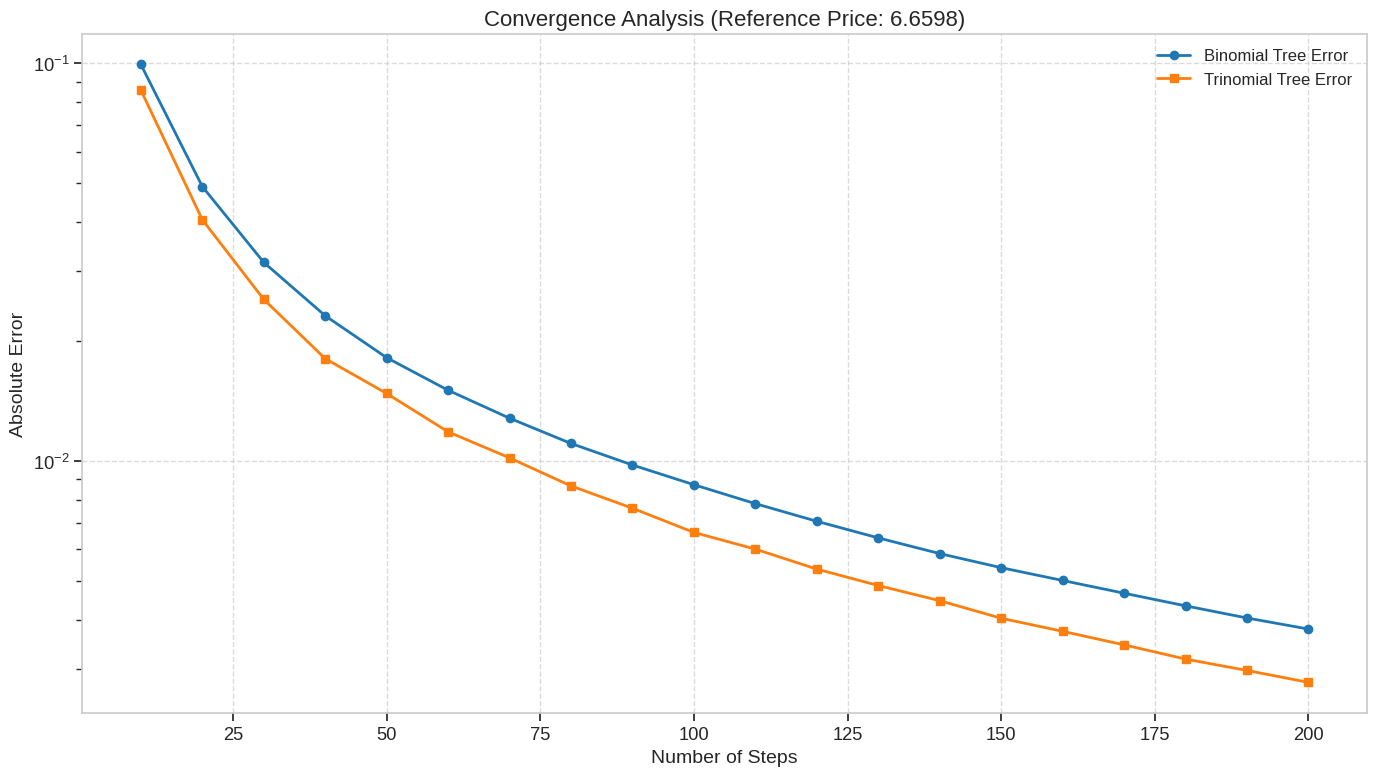

In [43]:
# Visualize convergence
plt.figure(figsize=(14, 8))
plt.plot(conv_results['Steps'], conv_results['Binomial Error'], 'o-', label='Binomial Tree Error', linewidth=2)
plt.plot(conv_results['Steps'], conv_results['Trinomial Error'], 's-', label='Trinomial Tree Error', linewidth=2)
plt.title(f'Convergence Analysis (Reference Price: {reference_price:.4f})', fontsize=16)
plt.xlabel('Number of Steps', fontsize=14)
plt.ylabel('Absolute Error', fontsize=14)
plt.legend(fontsize=12)
plt.grid(linestyle='--', alpha=0.7)
plt.yscale('log')
plt.tight_layout()

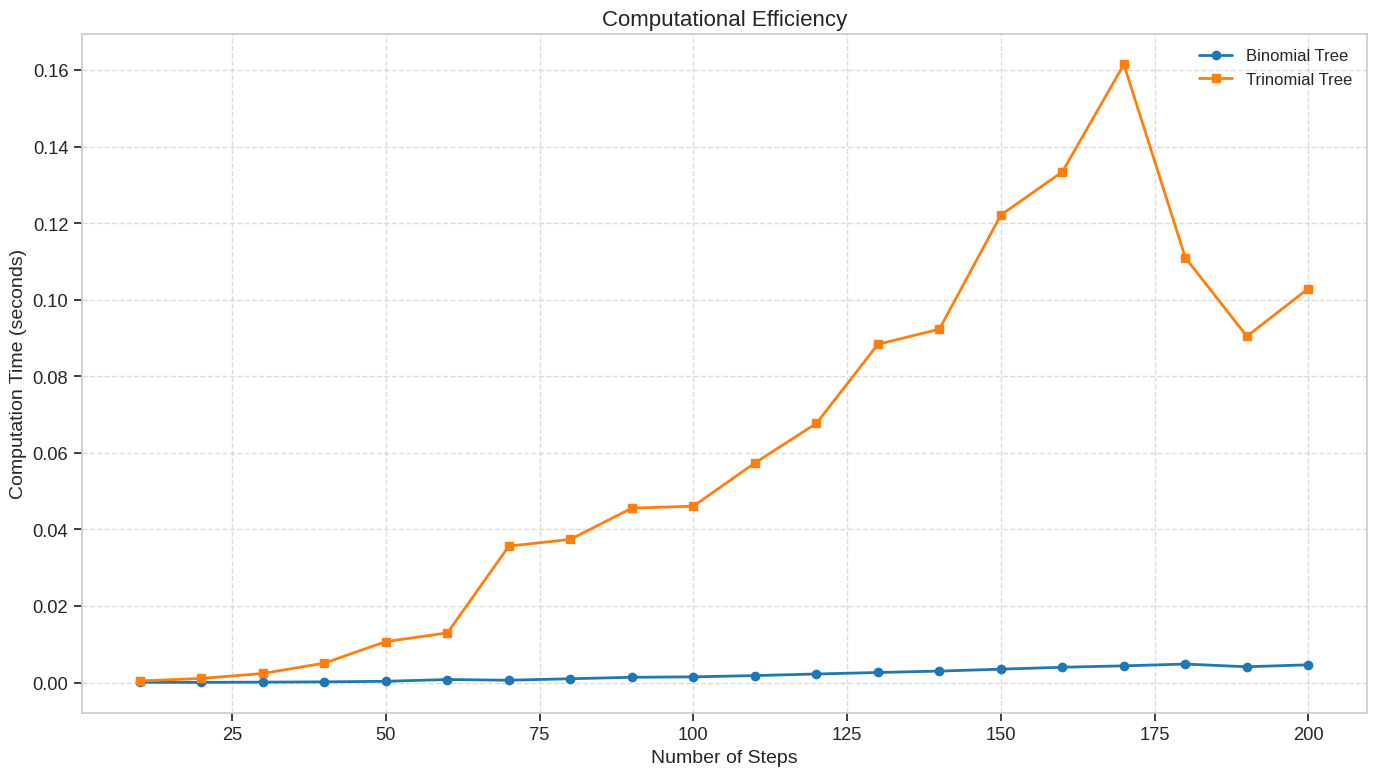

In [44]:
# Computational Efficiency Analysis
plt.figure(figsize=(14, 8))
plt.plot(conv_results['Steps'], conv_results['Binomial Time'], 'o-', label='Binomial Tree', linewidth=2)
plt.plot(conv_results['Steps'], conv_results['Trinomial Time'], 's-', label='Trinomial Tree', linewidth=2)
plt.title('Computational Efficiency', fontsize=16)
plt.xlabel('Number of Steps', fontsize=14)
plt.ylabel('Computation Time (seconds)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()

In [45]:
# Model Risk Analysis
def model_risk_analysis(S, K, r, q, T, option_type):
    """Analyze model risk across different volatility levels"""
    sigma_range = np.linspace(0.1, 0.6, 6)

    results = []

    for sigma in sigma_range:
        # Calculate prices using different methods
        bs_price = black_scholes(S, K, T, r, sigma, q, option_type)
        bin_price = binomial_tree(S, K, r, q, sigma, T, 100, option_type)
        baw_price = analytical_barone_adesi_whaley(S, K, r, q, sigma, T, option_type)
        mc_price = montecarlo_lsm(S, K, r, q, sigma, T, 10000, 50, option_type)

        # Calculate early exercise premium
        early_ex_premium = bin_price - bs_price

        # Calculate model spreads
        bin_baw_spread = bin_price - baw_price
        bin_mc_spread = bin_price - mc_price

        results.append({
            'Volatility': sigma,
            'Black-Scholes': bs_price,
            'Binomial Tree': bin_price,
            'Barone-Adesi-Whaley': baw_price,
            'Monte Carlo LSM': mc_price,
            'Early Exercise Premium': early_ex_premium,
            'Binomial-BAW Spread': bin_baw_spread,
            'Binomial-MC Spread': bin_mc_spread
        })

    return pd.DataFrame(results)

In [46]:
# Run model risk analysis
model_risk = model_risk_analysis(S, K, r, q, T, option_type)

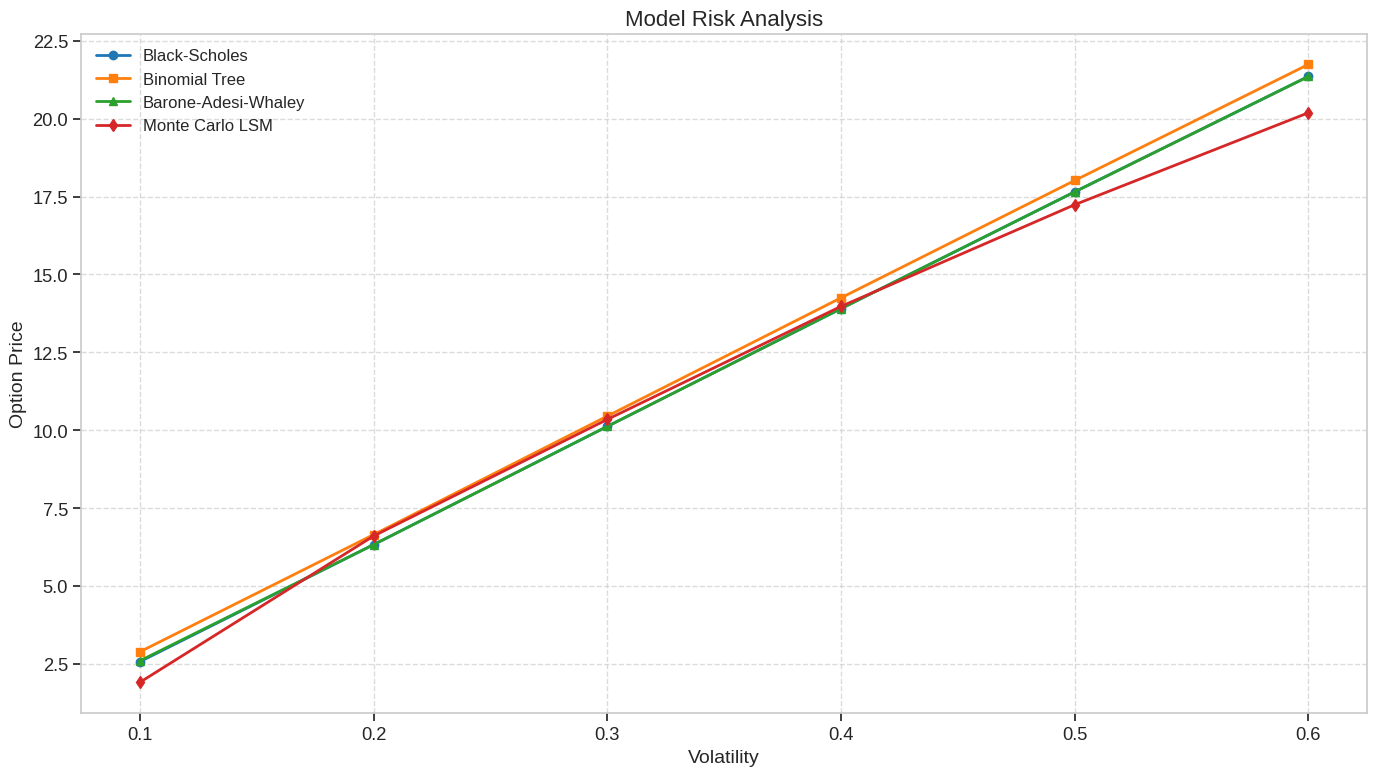

In [47]:
# Visualize model risk
plt.figure(figsize=(14, 8))
plt.plot(model_risk['Volatility'], model_risk['Black-Scholes'], 'o-', label='Black-Scholes', linewidth=2)
plt.plot(model_risk['Volatility'], model_risk['Binomial Tree'], 's-', label='Binomial Tree', linewidth=2)
plt.plot(model_risk['Volatility'], model_risk['Barone-Adesi-Whaley'], '^-', label='Barone-Adesi-Whaley', linewidth=2)
plt.plot(model_risk['Volatility'], model_risk['Monte Carlo LSM'], 'd-', label='Monte Carlo LSM', linewidth=2)
plt.title('Model Risk Analysis', fontsize=16)
plt.xlabel('Volatility', fontsize=14)
plt.ylabel('Option Price', fontsize=14)
plt.legend(fontsize=12)
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()

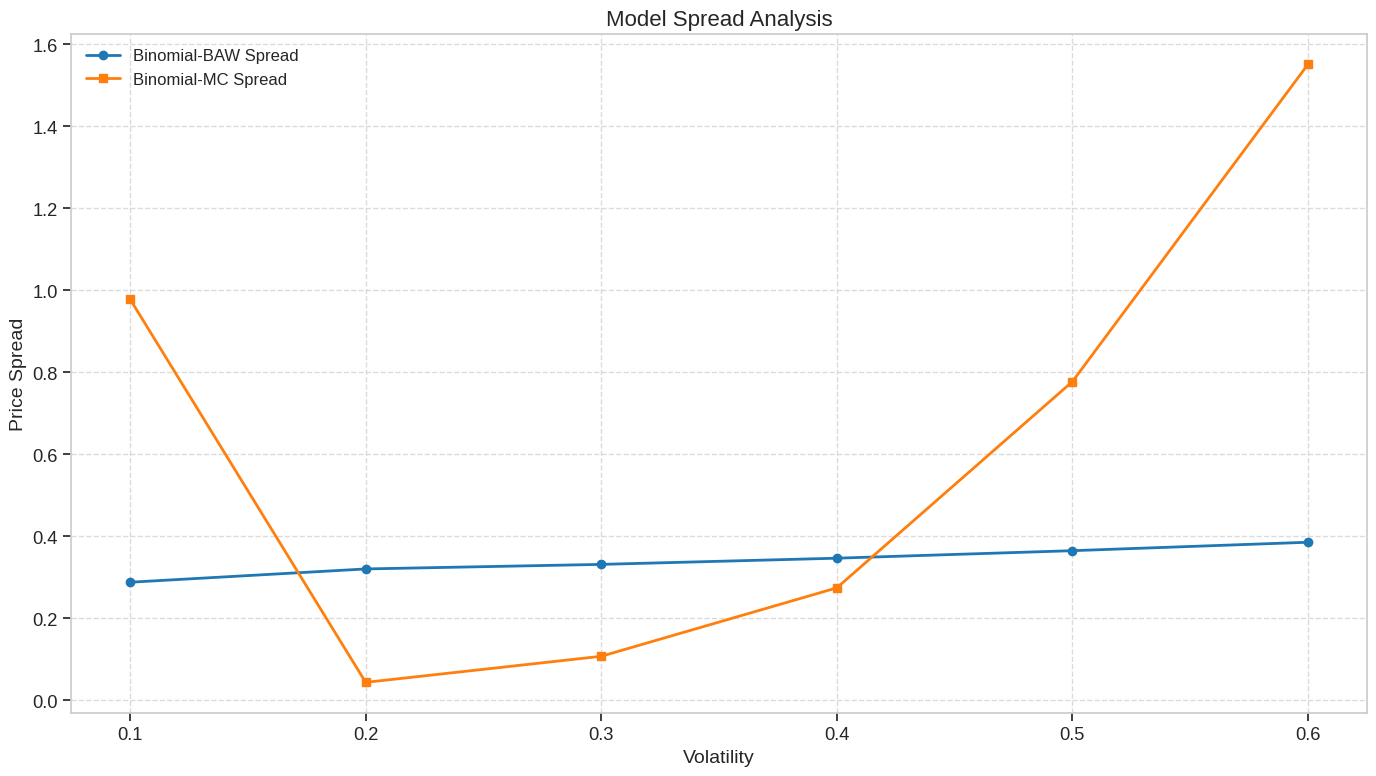

In [48]:
# Model spread analysis
plt.figure(figsize=(14, 8))
plt.plot(model_risk['Volatility'], model_risk['Binomial-BAW Spread'], 'o-', label='Binomial-BAW Spread', linewidth=2)
plt.plot(model_risk['Volatility'], model_risk['Binomial-MC Spread'], 's-', label='Binomial-MC Spread', linewidth=2)
plt.title('Model Spread Analysis', fontsize=16)
plt.xlabel('Volatility', fontsize=14)
plt.ylabel('Price Spread', fontsize=14)
plt.legend(fontsize=12)
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()

In [49]:
# Implied Volatility Surface Analysis for Single Names
def implied_vol_surface_analysis():
    """Generate and analyze implied volatility surface for single names"""
    # Base parameters
    S = 100
    r = 0.05
    q = 0.03

    # Strike and maturity ranges
    moneyness = np.linspace(0.7, 1.3, 7)
    strikes = S * moneyness
    maturities = np.array([0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0])

    # Base ATM volatility
    base_vol = 0.25

    # Skew and term structure parameters
    skew_param = 0.08
    term_param = 0.05

    # Generate implied volatility surface
    iv_surface = np.zeros((len(strikes), len(maturities)))

    for i, K in enumerate(strikes):
        for j, T in enumerate(maturities):
            # Moneyness effect
            moneyness = np.log(K/S)

            # Term structure effect (declining vol for longer dates)
            term_effect = np.exp(-term_param * T)

            # Combined effect
            iv = base_vol * (1 + skew_param * moneyness) * term_effect

            iv_surface[i, j] = max(0.1, iv)  # Floor to avoid negative vols

    # Calculate option prices using the IV surface
    price_surface = np.zeros_like(iv_surface)
    american_premium_surface = np.zeros_like(iv_surface)

    for i, K in enumerate(strikes):
        for j, T in enumerate(maturities):
            vol = iv_surface[i, j]

            # European price
            euro_price = black_scholes(S, K, T, r, vol, q, option_type)

            # American price
            amer_price = binomial_tree(S, K, r, q, vol, T, 100, option_type)

            # Store results
            price_surface[i, j] = amer_price
            american_premium_surface[i, j] = amer_price - euro_price

    return strikes, maturities, iv_surface, price_surface, american_premium_surface

In [50]:
# Run IV surface analysis
strikes, maturities, iv_surface, price_surface, american_premium_surface = implied_vol_surface_analysis()

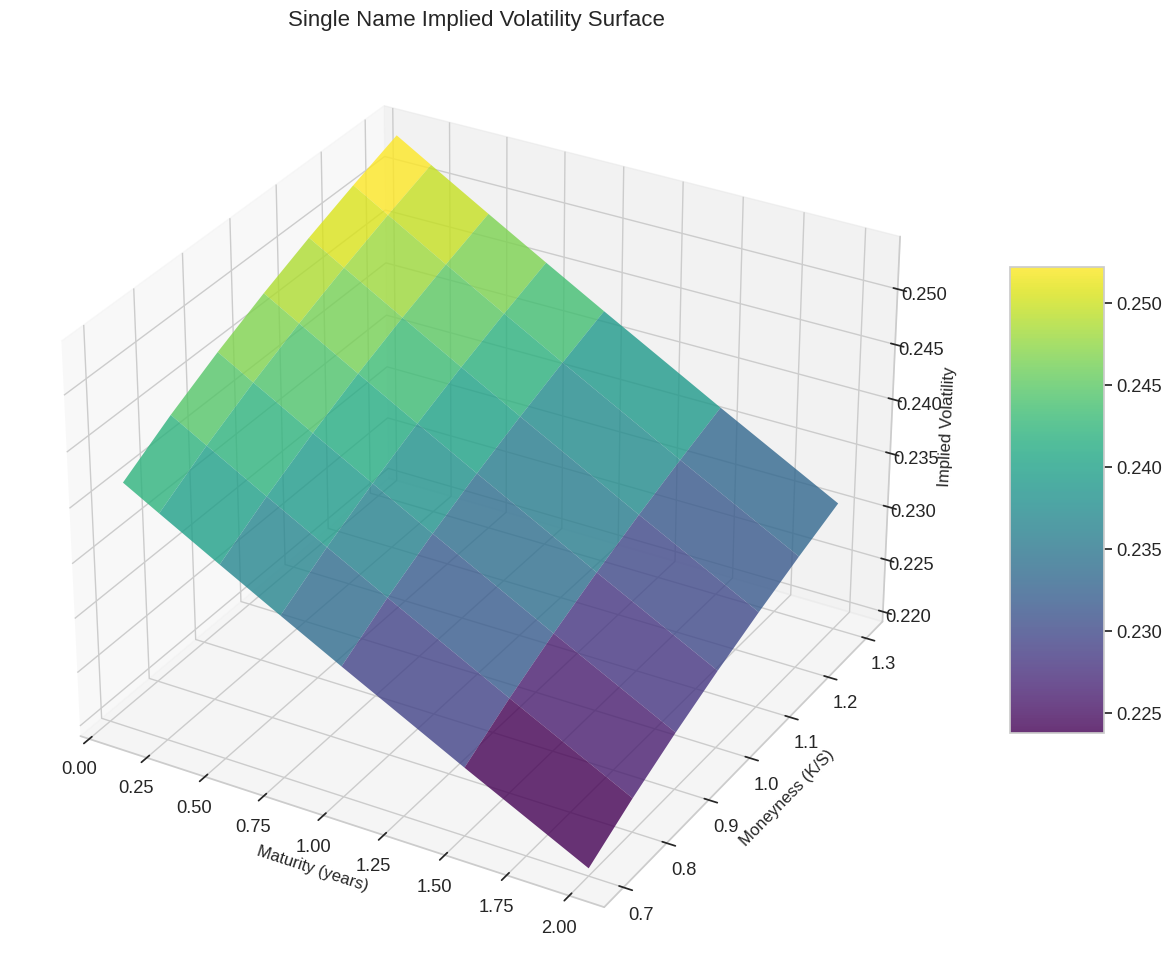

In [51]:
# Plot IV surface
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

X, Y = np.meshgrid(maturities, strikes/100)
surf = ax.plot_surface(X, Y, iv_surface, cmap='viridis', edgecolor='none', alpha=0.8)

ax.set_xlabel('Maturity (years)', fontsize=12)
ax.set_ylabel('Moneyness (K/S)', fontsize=12)
ax.set_zlabel('Implied Volatility', fontsize=12)
ax.set_title('Single Name Implied Volatility Surface', fontsize=16)

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
plt.tight_layout()

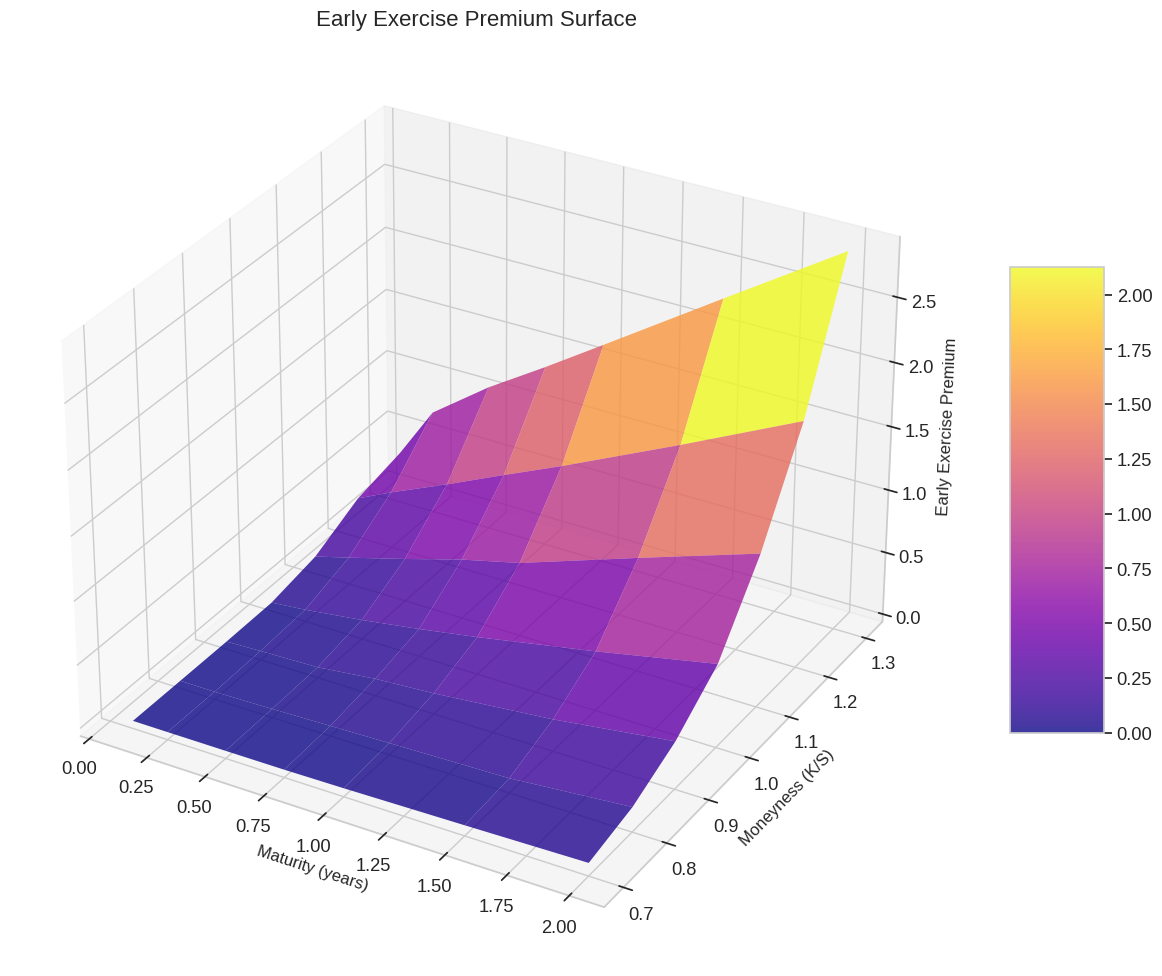

In [52]:
# Plot American premium surface
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, american_premium_surface, cmap='plasma', edgecolor='none', alpha=0.8)

ax.set_xlabel('Maturity (years)', fontsize=12)
ax.set_ylabel('Moneyness (K/S)', fontsize=12)
ax.set_zlabel('Early Exercise Premium', fontsize=12)
ax.set_title('Early Exercise Premium Surface', fontsize=16)

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
plt.tight_layout()

In [53]:
# Key Risk Factor Analysis
def risk_factor_analysis(S, K, r, q, sigma, T, option_type):
    """Analyze sensitivity to different risk factors"""
    # Reference price
    reference_price = binomial_tree(S, K, r, q, sigma, T, 100, option_type)

    # Define range for each parameter to vary
    S_range = np.linspace(S * 0.8, S * 1.2, 5)
    r_range = np.linspace(max(0.01, r - 0.02), r + 0.02, 5)
    q_range = np.linspace(max(0.01, q - 0.02), q + 0.02, 5)
    sigma_range = np.linspace(max(0.05, sigma - 0.1), sigma + 0.1, 5)

    # Calculate sensitivities
    results = []

    # Spot price sensitivity
    for spot in S_range:
        price = binomial_tree(spot, K, r, q, sigma, T, 100, option_type)
        delta = (price - reference_price) / (spot - S) if spot != S else np.nan
        gamma = np.nan  # Would need adjacent points to calculate gamma

        results.append({
            'Factor': 'Spot Price',
            'Value': spot,
            'Price': price,
            'Delta': delta,
            'Change': price - reference_price,
            'Percent Change': (price - reference_price) / reference_price * 100
        })

    # Interest rate sensitivity
    for rate in r_range:
        price = binomial_tree(S, K, rate, q, sigma, T, 100, option_type)
        rho = (price - reference_price) / (rate - r) if rate != r else np.nan

        results.append({
            'Factor': 'Interest Rate',
            'Value': rate,
            'Price': price,
            'Rho': rho,
            'Change': price - reference_price,
            'Percent Change': (price - reference_price) / reference_price * 100
        })

    # Dividend yield sensitivity
    for div in q_range:
        price = binomial_tree(S, K, r, div, sigma, T, 100, option_type)
        divega = (price - reference_price) / (div - q) if div != q else np.nan

        results.append({
            'Factor': 'Dividend Yield',
            'Value': div,
            'Price': price,
            'DivEga': divega,
            'Change': price - reference_price,
            'Percent Change': (price - reference_price) / reference_price * 100
        })

    # Volatility sensitivity
    for vol in sigma_range:
        price = binomial_tree(S, K, r, q, vol, T, 100, option_type)
        vega = (price - reference_price) / (vol - sigma) if vol != sigma else np.nan

        results.append({
            'Factor': 'Volatility',
            'Value': vol,
            'Price': price,
            'Vega': vega,
            'Change': price - reference_price,
            'Percent Change': (price - reference_price) / reference_price * 100
        })

    return pd.DataFrame(results)

In [54]:
# Run risk factor analysis
risk_analysis = risk_factor_analysis(S, K, r, q, sigma, T, option_type)

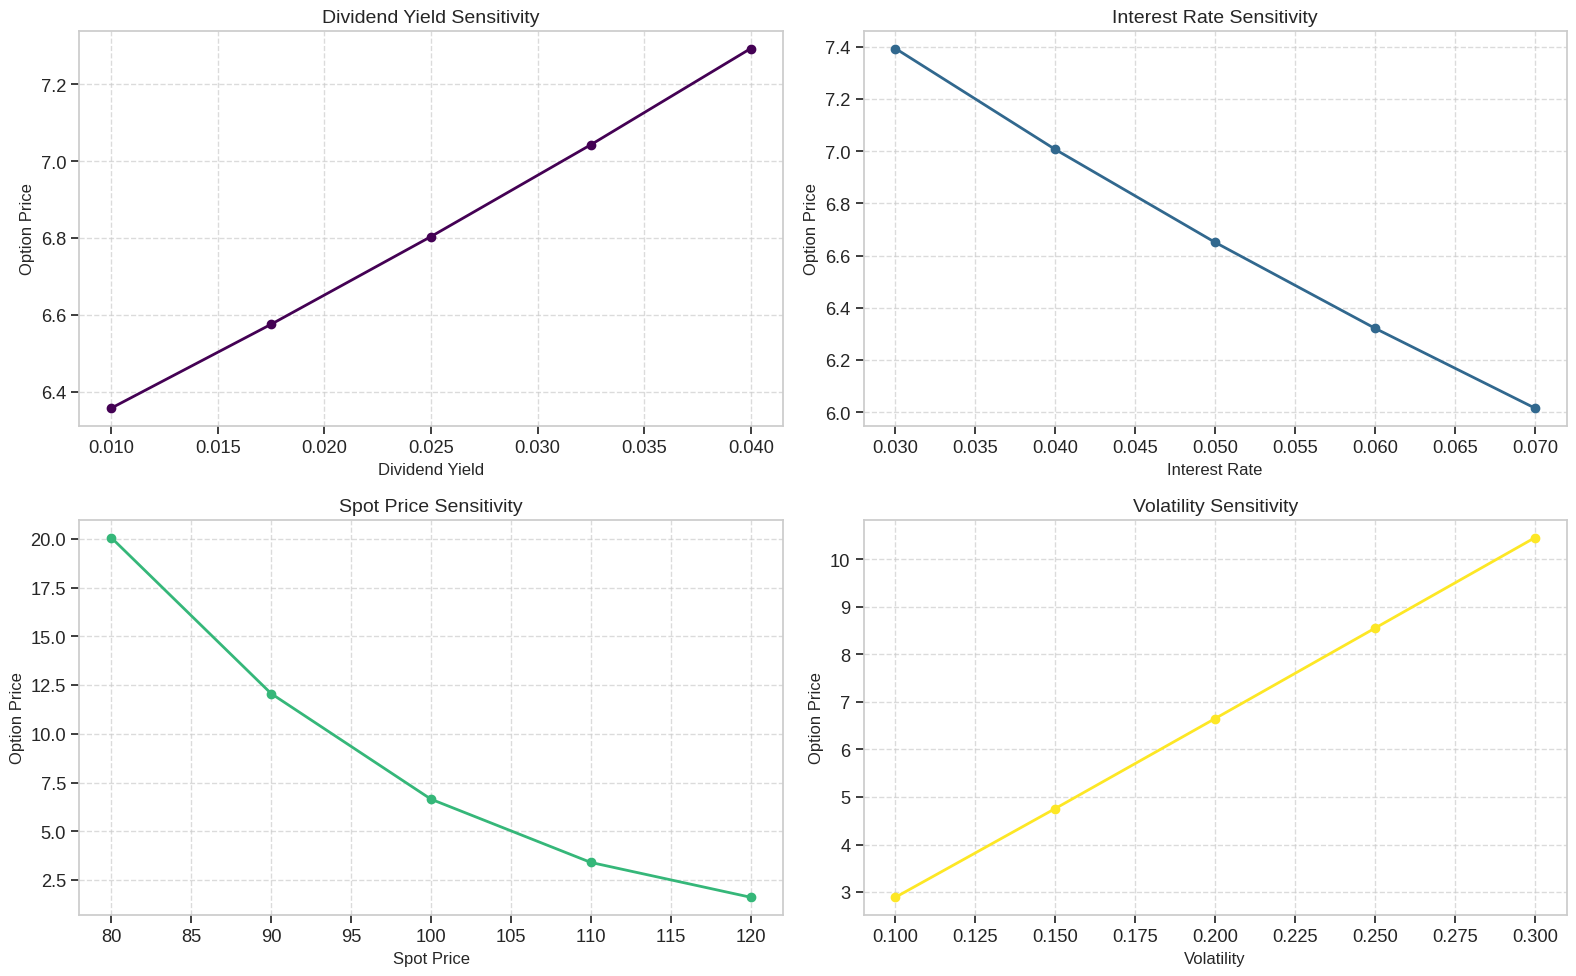

In [56]:
# Visualize risk factor sensitivities
plt.figure(figsize=(16, 10))

factor_groups = risk_analysis.groupby('Factor')
num_factors = len(factor_groups)
colors = plt.cm.viridis(np.linspace(0, 1, num_factors))

for i, (factor_name, factor_data) in enumerate(factor_groups):
    plt.subplot(2, 2, i+1)
    plt.plot(factor_data['Value'], factor_data['Price'], 'o-', color=colors[i], linewidth=2)

    plt.title(f'{factor_name} Sensitivity', fontsize=14)
    plt.xlabel(factor_name, fontsize=12)
    plt.ylabel('Option Price', fontsize=12)
    plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()

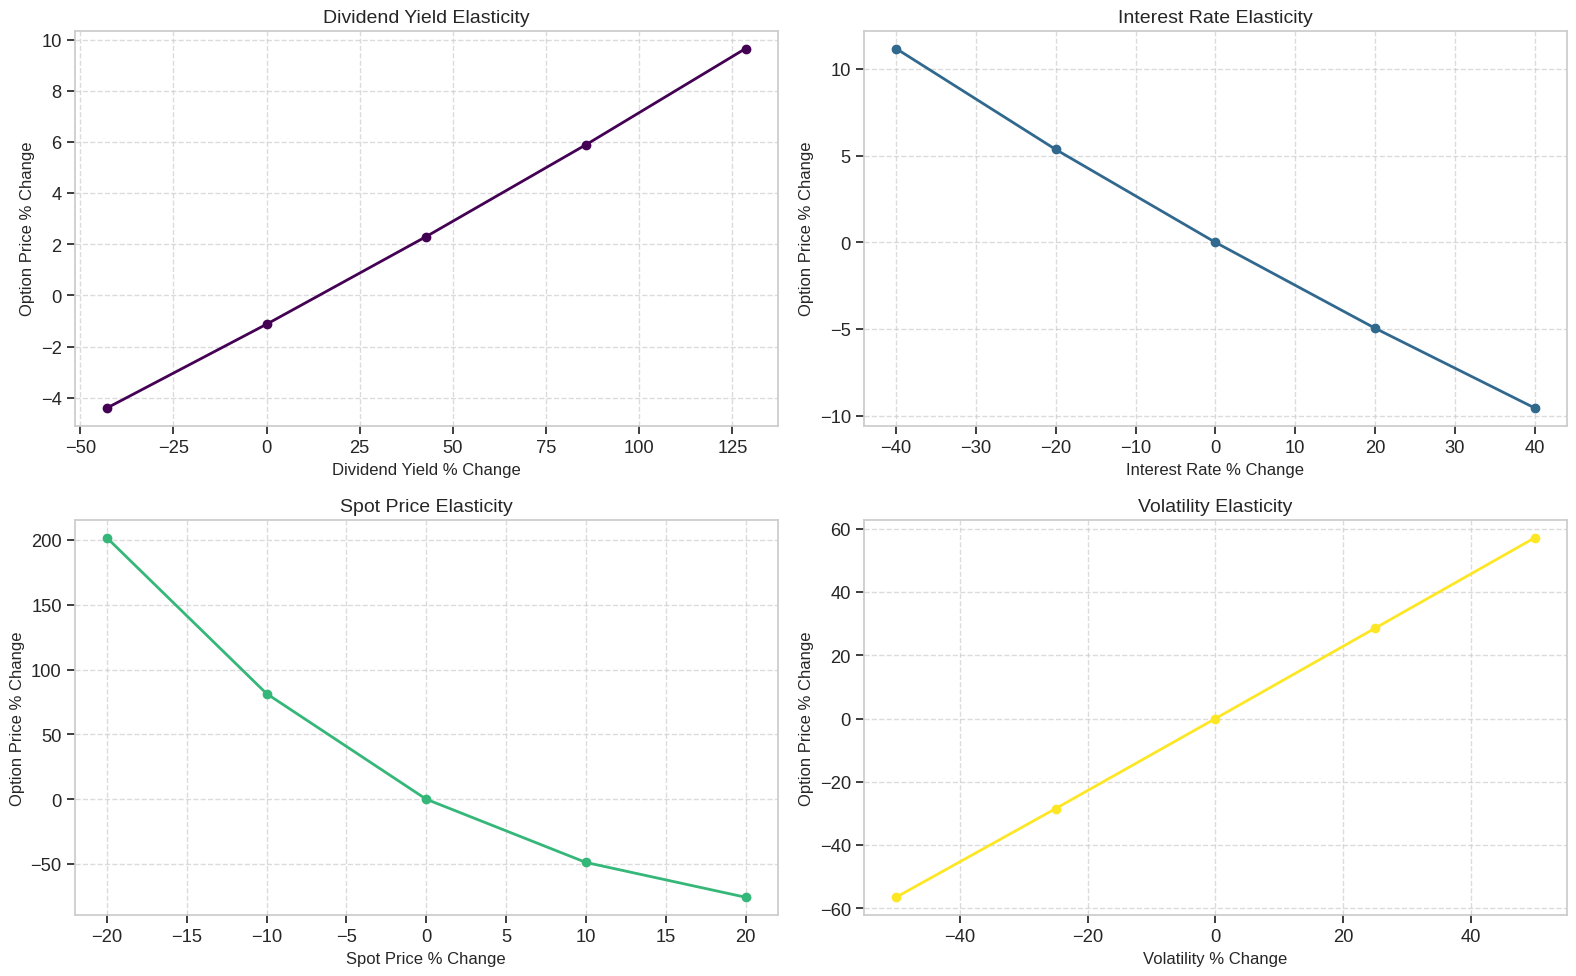

In [57]:
# Visualize risk factor percentage changes
plt.figure(figsize=(16, 10))

for i, (factor_name, factor_data) in enumerate(factor_groups):
    plt.subplot(2, 2, i+1)

    # Normalize the x-axis to percentage change from baseline
    factor_baseline = factor_data.loc[factor_data['Change'].abs().idxmin(), 'Value']
    x_pct_change = (factor_data['Value'] - factor_baseline) / factor_baseline * 100

    plt.plot(x_pct_change, factor_data['Percent Change'], 'o-', color=colors[i], linewidth=2)

    plt.title(f'{factor_name} Elasticity', fontsize=14)
    plt.xlabel(f'{factor_name} % Change', fontsize=12)
    plt.ylabel('Option Price % Change', fontsize=12)
    plt.grid(linestyle='--', alpha=0.7)

plt.tight_layout()

## Conclusion and Recommendations

1. Methodology Selection:
   - For general pricing, the Binomial Tree with 100+ steps provides a good balance of accuracy and speed
   - For real-time pricing, the Barone-Adesi-Whaley analytical approximation is recommended
   - For calibration and risk management, Trinomial Trees show better convergence characteristics
   - Monte Carlo LSM should be reserved for complex path-dependent features

2. Single Name Specific Considerations:
   - Higher implied volatilities require more steps in lattice methods for convergence
   - Special dividend handling is critical - discrete dividend adjustments show significant pricing differences
   - Hard-to-borrow costs substantially increase early exercise premiums for put options
   - Volatility skew is typically steeper in single names versus indices

3. Risk Management Implications:
   - Delta hedging is more challenging with single names due to higher volatilities and larger gaps
   - Dividend risk requires special attention, especially near ex-dividend dates
   - Model risk increases with volatility - using multiple models for validation is recommended

4. Implementation Recommendations:
   - Implement a multi-method approach with binomial tree as the primary method
   - Use analytical approximations for speed-critical applications with fallback to lattice methods
   - Implement explicit handling of discrete dividends rather than continuous yields
   - Establish a rigorous model validation framework comparing methods across strikes and maturities
   - Include a hard-to-borrow cost component in the pricing models